
-----

# 📘 ML Project - Week 3: Model Creation, Evaluation & Tuning
-----

## 1\. Setup & Data Preparation
**Q1:** Import the necessary libraries.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay 


sns.set(style="whitegrid")
%matplotlib inline


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Q2:** Load the  dataset and display the first 5 rows.

In [4]:
df = pd.read_csv('cardio_cleaned_week2.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,MAP,bmi_cat
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.97,90.000000,2
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.93,106.666667,4
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.51,90.000000,2
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.71,116.666667,3
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.01,73.333333,2


**Q3:** Separate the dataset into Features (`X`) and Target (`y`).

In [5]:
X = df.drop(['cardio','age','bmi_cat', 'id'], axis=1)
y = df['cardio']


-----

## 2\. Train-Test Split (Step 1)
**Q4:** Split the dataset into Training(80%) and Testing (20%) .

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Shape =: {X_train.shape}")
print(f"Testing Shape=:  {X_test.shape}")

Training Shape =: (54912, 13)
Testing Shape=:  (13729, 13)


-----

## 3\. Normalization / Scaling (Step 2)

**Q6:** Scale the data:

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Scaled Successfully.")

Data Scaled Successfully.


-----

## 4\. Model Training
**Q8:** Initialize the **Model**.

In [8]:
model1 = RandomForestClassifier(
    #no. of tree
    n_estimators=450,
    #layor of tree
    max_depth=12,
    #minimum sample need for for split 
    min_samples_split=15,
    #after spilt need sample for become leaf node
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
)


In [9]:
model2 = GradientBoostingClassifier(
  # no. of tree   
    n_estimators=300,
 #CORREAT ERROR RATE
    learning_rate=0.04, 
    max_depth=4, #if low then underfitting and if high then overfitting
    min_samples_split=20,
    min_samples_leaf=15,
    #random select 80% of dataset for training
    subsample=0.8,
    #10% of taining data keep as validation
    validation_fraction=0.1,
    #for stop training if validation score not imporeve
    n_iter_no_change=10,
    random_state=42
)

In [10]:
model3 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced', C=0.1)
model4 = LinearSVC(random_state=42, dual=False, class_weight='balanced', C=0.01)
model5 = KNeighborsClassifier(n_neighbors=13, weights='distance', metric='manhattan')
model6 = DecisionTreeClassifier(random_state=42, class_weight='balanced', criterion='entropy', max_depth=10, min_samples_leaf=50)

**Q9:** Train (fit) the model using the **Scaled Training Data**.

In [11]:
model1.fit(X_train_scaled, y_train)
model2.fit(X_train_scaled, y_train)
model3.fit(X_train_scaled, y_train)
model4.fit(X_train_scaled, y_train)
model5.fit(X_train_scaled, y_train)
model6.fit(X_train_scaled, y_train)
print("All Models Trained succefully.")

All Models Trained succefully.


-----

## 5. Evaluation

**Q10:** predictions on the **Scaled Test Set** (`X_test_scaled`).

In [12]:
y_pred1 = model1.predict(X_test_scaled)
y_pred2 = model2.predict(X_test_scaled)
y_pred3 = model3.predict(X_test_scaled)
y_pred4 = model4.predict(X_test_scaled)
y_pred5 = model5.predict(X_test_scaled)
y_pred6 = model6.predict(X_test_scaled)


**Q11:** Calculate the **Accuracy Score**.

In [13]:
accuracy1 = accuracy_score(y_test, y_pred1)
print(f"RandomForestClassifier Accuracy: {accuracy1 * 100:.2f}%")
accuracy2 = accuracy_score(y_test, y_pred2)
print(f"GradientBoostingClassifier Accuracy: {accuracy2 * 100:.2f}%")
accuracy3 = accuracy_score(y_test, y_pred3)
print(f"Logistic Regression Accuracy: {accuracy3 * 100:.2f}%")
accuracy4 = accuracy_score(y_test, y_pred4)
print(f"Linear SVC Accuracy: {accuracy4 * 100:.2f}%")
accuracy5 = accuracy_score(y_test, y_pred5)
print(f"KNN Accuracy: {accuracy5 * 100:.2f}%")
accuracy6 = accuracy_score(y_test, y_pred6)
print(f"Decision Tree Accuracy: {accuracy6 * 100:.2f}%")

RandomForestClassifier Accuracy: 73.22%
GradientBoostingClassifier Accuracy: 73.14%
Logistic Regression Accuracy: 72.34%
Linear SVC Accuracy: 72.30%
KNN Accuracy: 70.70%
Decision Tree Accuracy: 72.60%


**Q12:** Display the **Confusion Matrix** using a Heatmap.


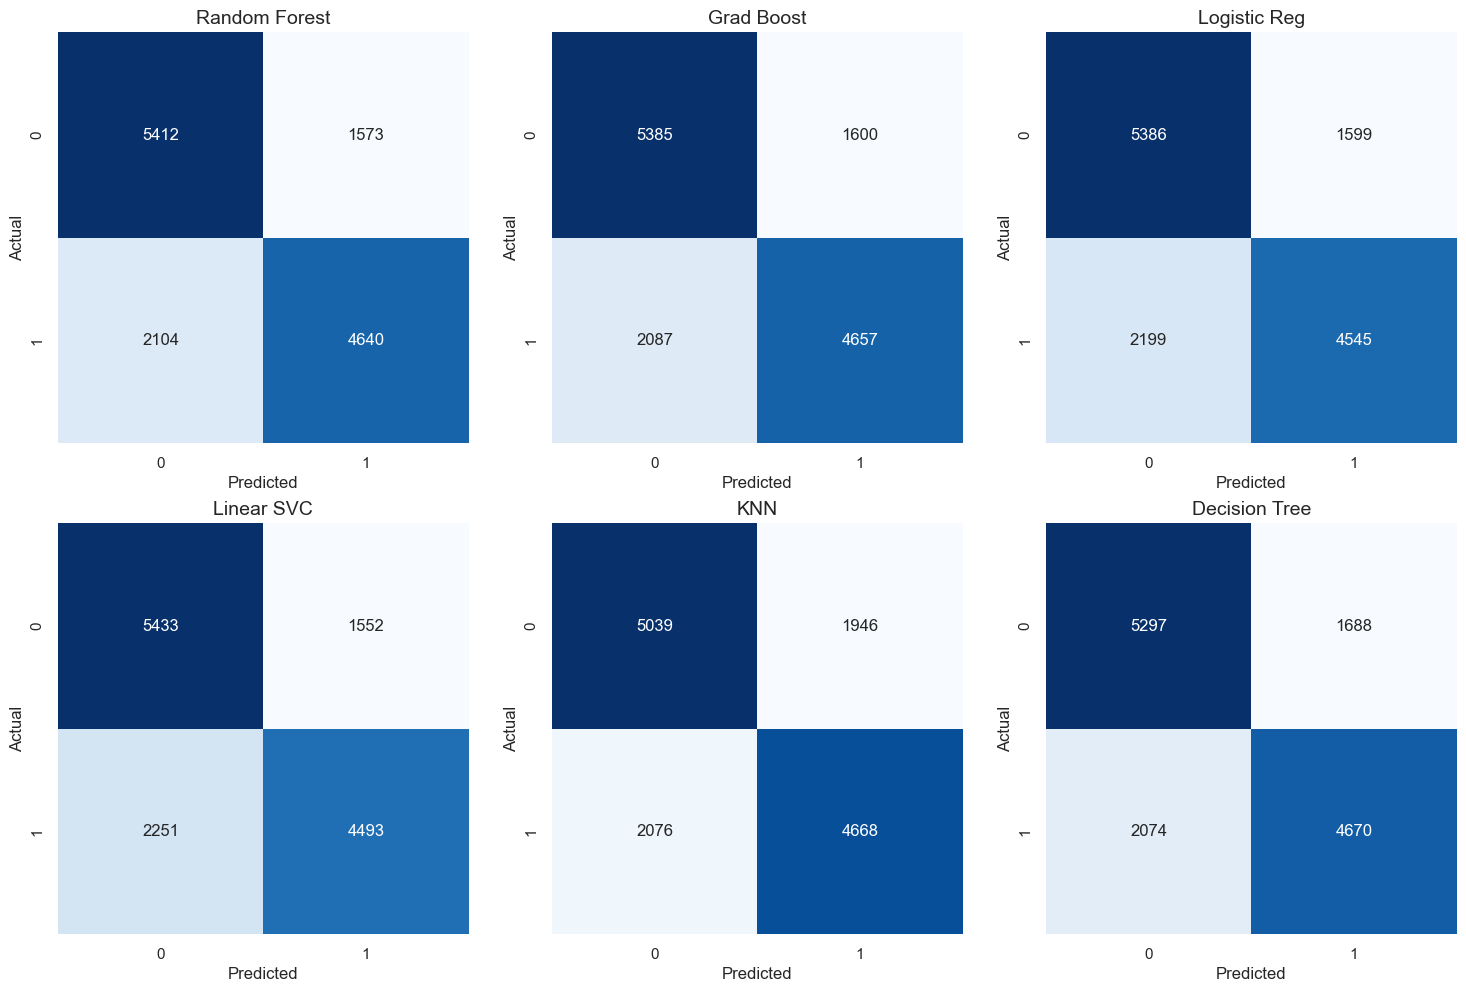

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

predictions = [y_pred1, y_pred2, y_pred3, y_pred4, y_pred5, y_pred6]
model_names = ['Random Forest', 'Grad Boost', 'Logistic Reg', 'Linear SVC', 'KNN', 'Decision Tree']

for i, pred in enumerate(predictions):
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                ax=axes[i], square=True, linewidths=0)
    
    axes[i].set_title(model_names[i], fontsize=14)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    

plt.tight_layout()
plt.show()

**Q13:** Print the full **Classification Report** (Precision, Recall, F1-Score).

In [15]:
models = [model1, model2, model3, model4, model5, model6]
model_names = ['Random Forest', 'Gradient Boosting', 'Logistic Regression', 'Linear SVC', 'K-Nearest Neighbors', 'Decision Tree']
predictions = [y_pred1, y_pred2, y_pred3, y_pred4, y_pred5, y_pred6]

print("="*60)
print("FINAL MODEL COMPARISON REPORT")
print("="*60)

for name, pred in zip(model_names, predictions):
    print(f"\n--- {name} ---")
    print(classification_report(y_test, pred))

FINAL MODEL COMPARISON REPORT

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.72      0.77      0.75      6985
           1       0.75      0.69      0.72      6744

    accuracy                           0.73     13729
   macro avg       0.73      0.73      0.73     13729
weighted avg       0.73      0.73      0.73     13729


--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6985
           1       0.74      0.69      0.72      6744

    accuracy                           0.73     13729
   macro avg       0.73      0.73      0.73     13729
weighted avg       0.73      0.73      0.73     13729


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6985
           1       0.74      0.67      0.71      6744

    accuracy                           0.72     13729
   macro avg       

-----

## 6. Overfitting & Underfitting Check

**Q14:** check Overfitting

In [16]:
y_train_pred = model2.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred3)

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Testing Accuracy:  {test_acc*100:.2f}%")

if (train_acc - test_acc) > 0.10:
    print("Warning: Potential Overfitting detected.")
else:
    print("Good Fit: Train & Test scores are balanced.")

Training Accuracy: 74.06%
Testing Accuracy:  72.34%
Good Fit: Train & Test scores are balanced.


-----

## Hyperparameter Tuning of knn using gridsearch



In [17]:
from sklearn.model_selection import GridSearchCV
# Initialize KNN
knn = KNeighborsClassifier()

# Define the grid
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 21], # Odd numbers to avoid ties
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Setup Grid Search
knn_grid = GridSearchCV(knn, knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit
knn_grid.fit(X_train_scaled, y_train)

print(f"Best KNN Params: {knn_grid.best_params_}")
print(f"Best KNN Accuracy: {knn_grid.best_score_:.2f}")

Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
Best KNN Accuracy: 0.72


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get the best model and make predictions
best_knn = knn_grid.best_estimator_
y_pred_tuned = best_knn.predict(X_test_scaled)

# 2. Print the report
print("="*30)
print("TUNED KNN CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_test, y_pred_tuned))

# 3. Quick comparison check
tuned_acc = best_knn.score(X_test_scaled, y_test) * 100
print(f"Original Accuracy: 70.70%")
print(f"Tuned Accuracy:    {tuned_acc:.2f}%")
print(f"Improvement:       {tuned_acc - 70.70:.2f}%")

TUNED KNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.71      0.76      0.73      6985
           1       0.73      0.68      0.71      6744

    accuracy                           0.72     13729
   macro avg       0.72      0.72      0.72     13729
weighted avg       0.72      0.72      0.72     13729

Original Accuracy: 70.70%
Tuned Accuracy:    72.15%
Improvement:       1.45%


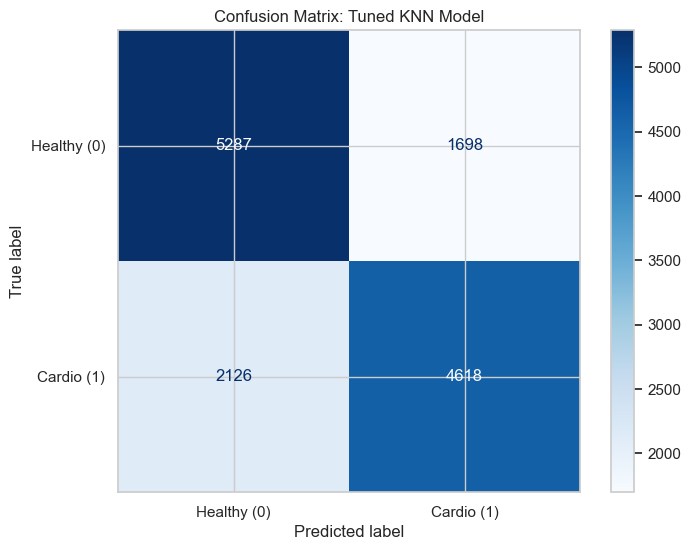

In [20]:
# Create the visualization
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Cardio (1)'])

disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Tuned KNN Model')
plt.show()

C:\Users\shyam\AppData\Local\Temp\ipykernel_1364\3727944925.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=scores, palette='viridis')
findfont: Font family 'bold' not found.
findfont: Font family 'bold' not found.
findfont: Font family 'bold' not found.
findfont: Font family 'bold' not found.
findfont: Font family 'bold' not found.
findfont: Font family 'bold' not found.
findfont: Font family 'bold' not found.
findfont: Font family 'bold' not found.


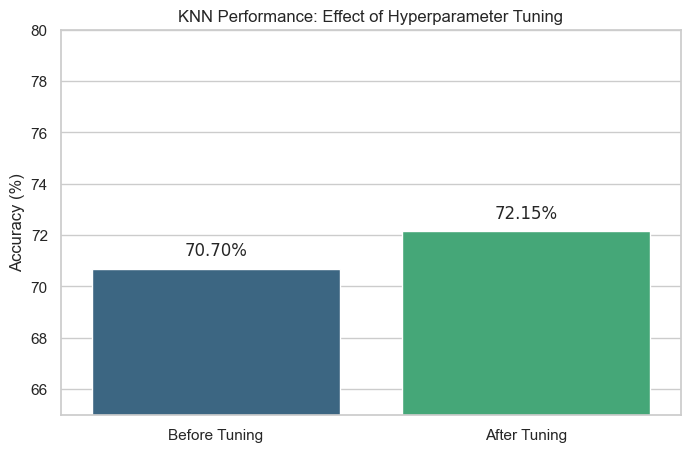

In [21]:
import seaborn as sns

# Data for plotting
labels = ['Before Tuning', 'After Tuning']
scores = [70.70, tuned_acc]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=scores, palette='viridis')
plt.ylim(65, 80) # Zoom in to see the difference clearly
plt.ylabel('Accuracy (%)')
plt.title('KNN Performance: Effect of Hyperparameter Tuning')

# Add text labels on top of bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', font='bold')

plt.show()

## Hyperparameter Tuning of Gradient Boosting using RandomSearch


In [22]:
from sklearn.model_selection import RandomizedSearchCV
# Initialize GB
gbc = GradientBoostingClassifier(random_state=42)

# Define a broad search space
gbc_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 6, 8],
    'min_samples_split': [10, 20, 40],
    'subsample': [0.7, 0.8, 0.9]
}

# n_iter=10 means it will pick 10 random combinations to test
gbc_random = RandomizedSearchCV(gbc, gbc_param_dist, n_iter=10, cv=5,






scoring='accuracy', random_state=42, n_jobs=-1)

# Fit
gbc_random.fit(X_train_scaled, y_train)

print(f"Best GB Params: {gbc_random.best_params_}")
print(f"Best GB Accuracy: {gbc_random.best_score_:.2f}")

Best GB Params: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_split': 10, 'max_depth': 6, 'learning_rate': 0.01}
Best GB Accuracy: 0.74


In [23]:
best_gbc = gbc_random.best_estimator_
y_pred_tuned_gbc = best_gbc.predict(X_test_scaled)

# 2. Print the report
print("="*30)
print("TUNED GBC CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_test, y_pred_tuned_gbc))

# 3. Quick comparison check
tuned_acc = best_gbc.score(X_test_scaled, y_test) * 100
print(f"Original Accuracy: 73.14%")
print(f"Tuned Accuracy:    {tuned_acc:.2f}%")
print(f"Improvement:       {tuned_acc - 73.14:.2f}%")

TUNED GBC CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.72      0.77      0.75      6985
           1       0.74      0.69      0.72      6744

    accuracy                           0.73     13729
   macro avg       0.73      0.73      0.73     13729
weighted avg       0.73      0.73      0.73     13729

Original Accuracy: 73.14%
Tuned Accuracy:    73.22%
Improvement:       0.08%


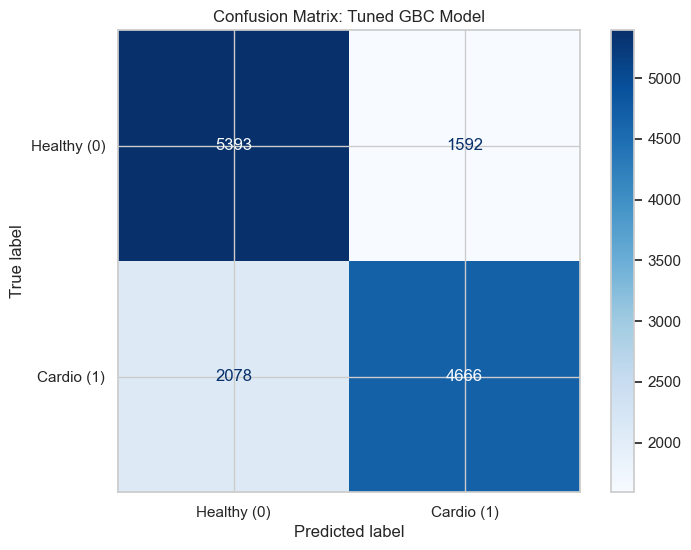

In [12]:
# Create the visualization
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_tuned_gbc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Cardio (1)'])

disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Tuned GBC Model')

plt.show()

C:\Users\shyam\AppData\Local\Temp\ipykernel_1364\3153581741.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=scores, palette='viridis')


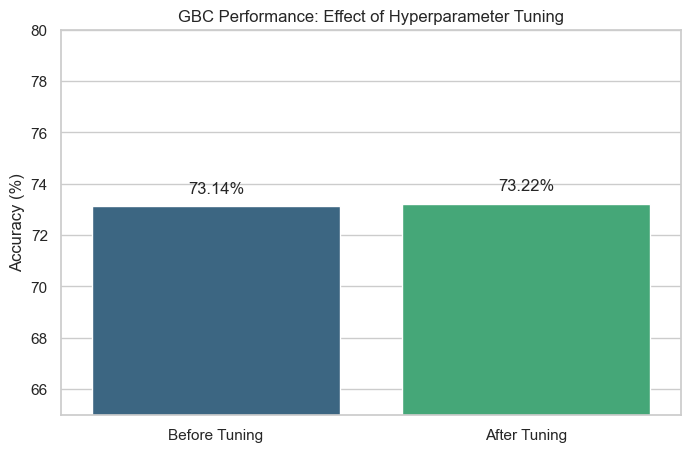

In [24]:
labels = ['Before Tuning', 'After Tuning']
scores = [73.14, tuned_acc]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=scores, palette='viridis')
plt.ylim(65, 80) # Zoom in to see the difference clearly
plt.ylabel('Accuracy (%)')
plt.title('GBC Performance: Effect of Hyperparameter Tuning')

for i, v in enumerate(scores):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')
plt.show()

plt.show()

In [25]:
import joblib
joblib.dump(best_gbc, "final_model.pkl")

['final_model.pkl']